In [11]:
# IMPORT LIBRARIES
# ================
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [12]:
# LOAD TEXT CORPUS
# ================
corpus = '''
Artificial intelligence is changing the future of technology.
Deep learning enables machines to learn complex patterns from data.
Recurrent neural networks process sequential information efficiently.
Long short term memory networks overcome the vanishing gradient problem.
Gated recurrent units are computationally efficient alternatives to LSTM.
Text generation models predict the next word based on previous context.
Deep learning is widely used in healthcare finance education and robotics.
Natural language processing helps computers understand human language.
'''
print(corpus)


Artificial intelligence is changing the future of technology.
Deep learning enables machines to learn complex patterns from data.
Recurrent neural networks process sequential information efficiently.
Long short term memory networks overcome the vanishing gradient problem.
Gated recurrent units are computationally efficient alternatives to LSTM.
Text generation models predict the next word based on previous context.
Deep learning is widely used in healthcare finance education and robotics.
Natural language processing helps computers understand human language.



In [13]:
# TOKENIZATION AND SEQUENCE CREATION
# ==================================
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])
total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)
input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)
max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')
X = input_sequences[:, :-1]
y = input_sequences[:, -1]
print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 66
X shape: (66, 10)
y shape: (66,)


In [14]:
# MODEL: Vanilla RNN
# ==================
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])
rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


In [15]:
# LSTM 
# ====
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])
lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


In [16]:
# GRU
# ===
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])
gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])
gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


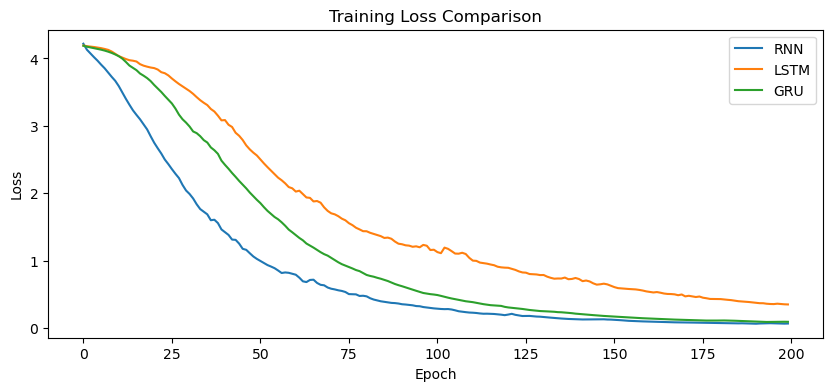

In [17]:
# COMPARING THE TRAINING LOSS 
# ===========================
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

In [18]:
# TEXT GENERATION FUNCTION
# ========================
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]
        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

In [19]:
# GENERATING TEXT SAMPLES
# =======================
print("RNN :", generate_text(rnn_model, "deep learning", 10))
print("LSTM:", generate_text(lstm_model, "deep learning", 10))
print("GRU :", generate_text(gru_model, "deep learning", 10))

RNN : deep learning is widely used in healthcare finance education and robotics the
LSTM: deep learning is widely used in healthcare finance education and robotics robotics
GRU : deep learning is widely used in healthcare finance education and robotics robotics
